# Donwloading data

Fetching stock data...



2 Failed downloads:
['PEAK', 'SIVB']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['SIVB']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['PEAK']: YFTzMissingError('possibly delisted; no timezone found')


Failed to download data for: ['SIVB', 'PEAK']
Trying individual download for SIVB...
Individual download also failed for SIVB
Trying individual download for PEAK...
Individual download also failed for PEAK

Successfully downloaded data for 28 out of 30 stocks:
Available stocks: ['JPM', 'WFC', 'BAC', 'C', 'GS', 'USB', 'MS', 'KEY', 'PNC', 'COF', 'AXP', 'PRU', 'SCHW', 'TFC', 'KR', 'PFE', 'XOM', 'WMT', 'DAL', 'CSCO', 'EQIX', 'DUK', 'NFLX', 'GE', 'APA', 'F', 'REGN', 'CMS']
Returns data saved to: /Users/alberto/Documents/projects/WQU/stochastimcModeling/report3/returns_2008.csv
Plotting stocks: ['JPM', 'BAC', 'NFLX', 'WMT', 'GE']


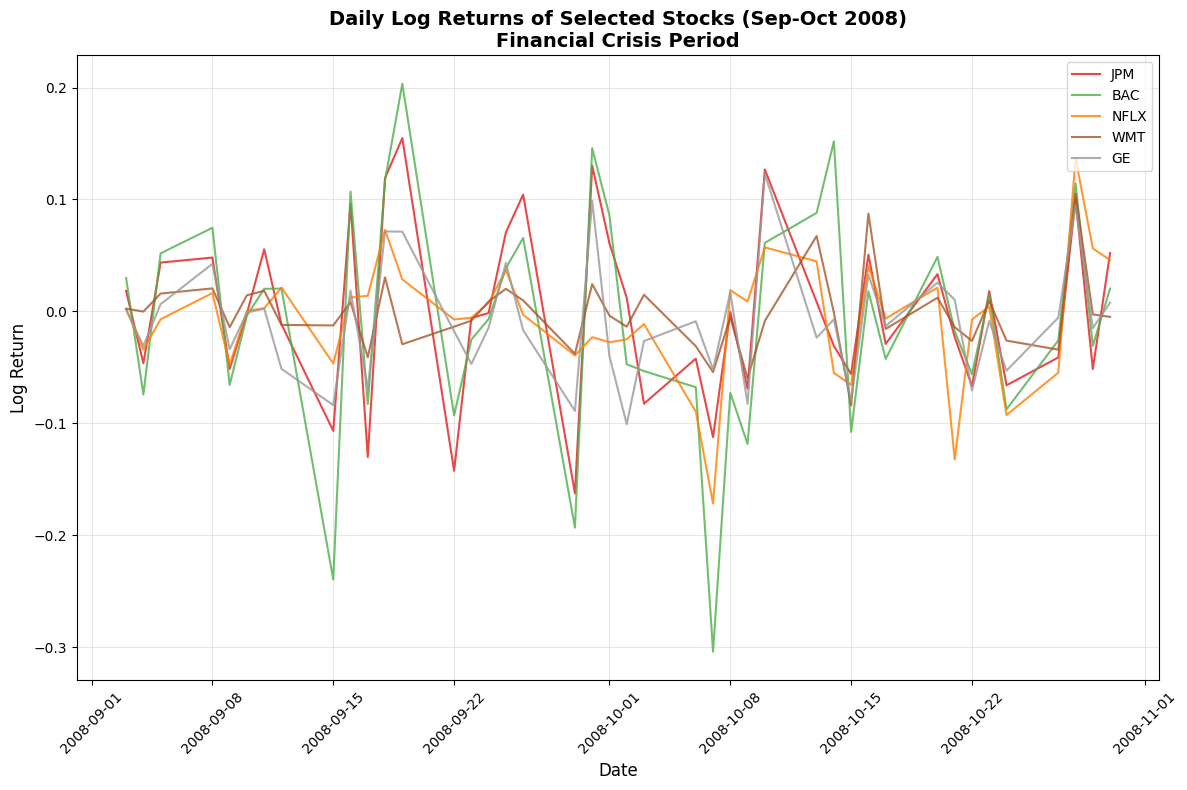

Plot saved to: /Users/alberto/Documents/projects/WQU/stochastimcModeling/report3/images/returns_plot.pdf

DATA SUMMARY
DataFrame Shape: (42, 28)
Date Range: 2008-09-03 to 2008-10-30
Number of Trading Days: 42
Stocks with Data: ['JPM', 'WFC', 'BAC', 'C', 'GS', 'USB', 'MS', 'KEY', 'PNC', 'COF', 'AXP', 'PRU', 'SCHW', 'TFC', 'KR', 'PFE', 'XOM', 'WMT', 'DAL', 'CSCO', 'EQIX', 'DUK', 'NFLX', 'GE', 'APA', 'F', 'REGN', 'CMS']

Basic Statistics:
             JPM        WFC        BAC          C         GS        USB  \
count  42.000000  42.000000  42.000000  42.000000  42.000000  42.000000   
mean   -0.000669   0.000476  -0.008084  -0.008675  -0.014114  -0.002494   
std     0.078004   0.068429   0.102153   0.095375   0.077046   0.048316   
min    -0.162616  -0.157552  -0.304163  -0.203885  -0.149850  -0.100156   
25%    -0.051519  -0.042631  -0.067281  -0.065367  -0.066679  -0.034019   
50%    -0.001628  -0.003489  -0.005314  -0.021261  -0.018334  -0.005644   
75%     0.051743   0.048113   0.058

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
from typing import List, Optional

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)

# Define the list of 30 S&P 500 stocks as specified in the paper
# Note: Some tickers may have changed since 2008
stocks = [
    # Financial institutions
    'JPM', 'WFC', 'BAC', 'C', 'GS', 'USB', 'MS', 'KEY', 'PNC', 'COF',
    'AXP', 'PRU', 'SCHW', 'TFC', 'SIVB',  # Changed BBT to TFC, STI to SIVB
    # Non-financial companies
    'KR', 'PFE', 'XOM', 'WMT', 'DAL', 'CSCO', 'PEAK', 'EQIX', 'DUK', 'NFLX',  # Changed HCP to PEAK
    'GE', 'APA', 'F', 'REGN', 'CMS'
]

# Define the date range for September and October 2008
start_date = '2008-09-01'
end_date = '2008-10-31'

def fetch_stock_data(tickers: List[str], start: str, end: str) -> pd.DataFrame:
    """
    Fetches daily closing prices for a list of tickers within the specified date range.
    Returns a pandas DataFrame with dates as index and tickers as columns.
    """
    try:
        # Use auto_adjust=False to avoid the warning and get consistent behavior
        data = yf.download(tickers, start=start, end=end, progress=False, 
                          auto_adjust=False, group_by='ticker')
        
        # Handle both single and multiple ticker scenarios
        if len(tickers) == 1:
            # For single ticker, yfinance returns a DataFrame with OHLCV columns
            if 'Adj Close' in data.columns:
                data = data[['Adj Close']].rename(columns={'Adj Close': tickers[0]})
            else:
                data = pd.DataFrame()
        else:
            # For multiple tickers, extract adjusted close prices
            adj_close_data = pd.DataFrame()
            for ticker in tickers:
                try:
                    if (ticker, 'Adj Close') in data.columns:
                        adj_close_data[ticker] = data[(ticker, 'Adj Close')]
                    elif ticker in data.columns and 'Adj Close' in data[ticker].columns:
                        adj_close_data[ticker] = data[ticker]['Adj Close']
                except (KeyError, AttributeError):
                    print(f"Warning: Could not extract data for {ticker}")
                    continue
            data = adj_close_data
        
        # Handle missing data by forward-filling (using new syntax)
        if not data.empty:
            data = data.ffill()
        
        return data
    
    except Exception as e:
        print(f"Error fetching data: {e}")
        return pd.DataFrame()

def try_alternative_tickers(failed_stocks: List[str]) -> List[str]:
    """
    Try alternative ticker symbols for stocks that failed to download.
    """
    ticker_mapping = {
        'BBT': 'TFC',  # BB&T became Truist Financial
        'STI': 'TFC',  # SunTrust became Truist Financial (merged with BBT)
        'HCP': 'PEAK', # Healthpeak Properties
    }
    
    alternatives = []
    for stock in failed_stocks:
        if stock in ticker_mapping:
            alternatives.append(ticker_mapping[stock])
        else:
            # For other failed stocks, we might need to research historical tickers
            print(f"No known alternative for {stock}")
    
    return alternatives

def fetch_data_with_retry(stocks: List[str], start_date: str, end_date: str) -> pd.DataFrame:
    """
    Fetch stock data with retry logic for failed downloads.
    """
    # First attempt
    price_data = fetch_stock_data(stocks, start_date, end_date)
    
    # Check for missing stocks
    missing_stocks = [stock for stock in stocks if stock not in price_data.columns or price_data[stock].isna().all()]
    
    if missing_stocks:
        print(f"Failed to download data for: {missing_stocks}")
        
        # Try individual downloads for failed stocks
        successful_data = price_data.copy()
        
        for stock in missing_stocks:
            print(f"Trying individual download for {stock}...")
            individual_data = fetch_stock_data([stock], start_date, end_date)
            
            if not individual_data.empty and stock in individual_data.columns:
                successful_data[stock] = individual_data[stock]
                print(f"Successfully downloaded {stock}")
            else:
                print(f"Individual download also failed for {stock}")
        
        return successful_data
    
    return price_data

# Fetch the data with retry logic
print("Fetching stock data...")
price_data = fetch_data_with_retry(stocks, start_date, end_date)

# Verify that we have some data
available_stocks = [stock for stock in stocks if stock in price_data.columns and not price_data[stock].isna().all()]

print(f"\nSuccessfully downloaded data for {len(available_stocks)} out of {len(stocks)} stocks:")
print(f"Available stocks: {available_stocks}")

if len(available_stocks) > 0:
    # Filter price_data to only include available stocks
    price_data = price_data[available_stocks]
    
    # Remove rows where all values are NaN
    price_data = price_data.dropna(how='all')
    
    if price_data.empty:
        print("No valid price data available after cleaning.")
    else:
        # Compute daily log returns: R_{i,t} = log(P_{i,t+1} / P_{i,t})
        returns_data = np.log(price_data / price_data.shift(1))
        
        # Drop the first row which contains NaN due to the shift
        returns_data = returns_data.dropna()
        
        # Check if returns_data is empty
        if returns_data.empty:
            print("No returns data available after processing.")
        else:
            # Create output directory
            output_dir = '/Users/alberto/Documents/projects/WQU/stochastimcModeling/report3'
            images_dir = os.path.join(output_dir, 'images')
            os.makedirs(output_dir, exist_ok=True)
            os.makedirs(images_dir, exist_ok=True)
            
            # Save the returns data to a CSV file for later use
            csv_path = os.path.join(output_dir, 'returns_2008.csv')
            returns_data.to_csv(csv_path)
            print(f"Returns data saved to: {csv_path}")
            
            # Generate a time series plot of returns for a subset of stocks
            plot_stocks = ['JPM', 'BAC', 'NFLX', 'WMT', 'GE']  # Preferred subset
            
            # Filter out stocks that don't have data
            available_plot_stocks = [stock for stock in plot_stocks if stock in returns_data.columns]
            
            if not available_plot_stocks:
                # If none of the preferred stocks are available, use the first 5 available stocks
                available_plot_stocks = list(returns_data.columns)[:5]
            
            print(f"Plotting stocks: {available_plot_stocks}")
            
            if available_plot_stocks:
                plt.figure(figsize=(12, 8))
                
                # Create subplots for better visualization
                colors = plt.cm.Set1(np.linspace(0, 1, len(available_plot_stocks)))
                
                for i, stock in enumerate(available_plot_stocks):
                    plt.plot(returns_data.index, returns_data[stock], 
                           label=stock, color=colors[i], linewidth=1.5, alpha=0.8)
                
                plt.title('Daily Log Returns of Selected Stocks (Sep-Oct 2008)\nFinancial Crisis Period', 
                         fontsize=14, fontweight='bold')
                plt.xlabel('Date', fontsize=12)
                plt.ylabel('Log Return', fontsize=12)
                plt.legend(loc='upper right', fontsize=10)
                plt.grid(True, alpha=0.3)
                
                # Improve date formatting on x-axis
                plt.xticks(rotation=45)
                plt.tight_layout()
                
                # Save the plot
                plot_path = os.path.join(images_dir, 'returns_plot.pdf')
                plt.savefig(plot_path, format='pdf', bbox_inches='tight', dpi=300)
                plt.show()
                print(f"Plot saved to: {plot_path}")
            else:
                print("No stocks available for plotting")
            
            # Print summary information about the data
            print(f"\n{'='*50}")
            print("DATA SUMMARY")
            print(f"{'='*50}")
            print(f"DataFrame Shape: {returns_data.shape}")
            print(f"Date Range: {returns_data.index[0].strftime('%Y-%m-%d')} to {returns_data.index[-1].strftime('%Y-%m-%d')}")
            print(f"Number of Trading Days: {len(returns_data)}")
            print(f"Stocks with Data: {list(returns_data.columns)}")
            
            print("\nBasic Statistics:")
            print(returns_data.describe().round(6))
            
            print(f"\n{'='*50}")
            print("SAMPLE RETURNS DATA (First 10 Days)")
            print(f"{'='*50}")
            print(returns_data.head(10).round(6))
            
            # Additional analysis: Check for extreme returns during the crisis
            print(f"\n{'='*50}")
            print("EXTREME RETURNS ANALYSIS")
            print(f"{'='*50}")
            
            # Find the most volatile days
            daily_volatility = returns_data.abs().sum(axis=1).sort_values(ascending=False)
            print("Top 5 Most Volatile Days (Sum of Absolute Returns):")
            for date, vol in daily_volatility.head().items():
                print(f"{date.strftime('%Y-%m-%d')}: {vol:.4f}")
            
            # Stock-specific volatility
            stock_volatility = returns_data.std().sort_values(ascending=False)
            print(f"\nStock Volatility (Standard Deviation):")
            for stock, vol in stock_volatility.items():
                print(f"{stock}: {vol:.4f}")

else:
    print("No stock data available for the specified period")
    print("This might be due to:")
    print("1. Delisted companies")
    print("2. Changed ticker symbols")
    print("3. Data availability issues for the 2008 period")
    print("4. Network connectivity issues")

# Correlation matrix

Successfully loaded returns data with shape: (42, 28)
Stocks available: ['JPM', 'WFC', 'BAC', 'C', 'GS', 'USB', 'MS', 'KEY', 'PNC', 'COF', 'AXP', 'PRU', 'SCHW', 'TFC', 'KR', 'PFE', 'XOM', 'WMT', 'DAL', 'CSCO', 'EQIX', 'DUK', 'NFLX', 'GE', 'APA', 'F', 'REGN', 'CMS']
Data shape after cleaning: (42, 28)
Computing correlation matrix using custom formula...
Computing correlation matrix using pandas built-in function for comparison...
Correlation matrix shape: (28, 28)
Any NaN values in custom correlation matrix: False
Any infinite values in custom correlation matrix: False
Performing hierarchical clustering...


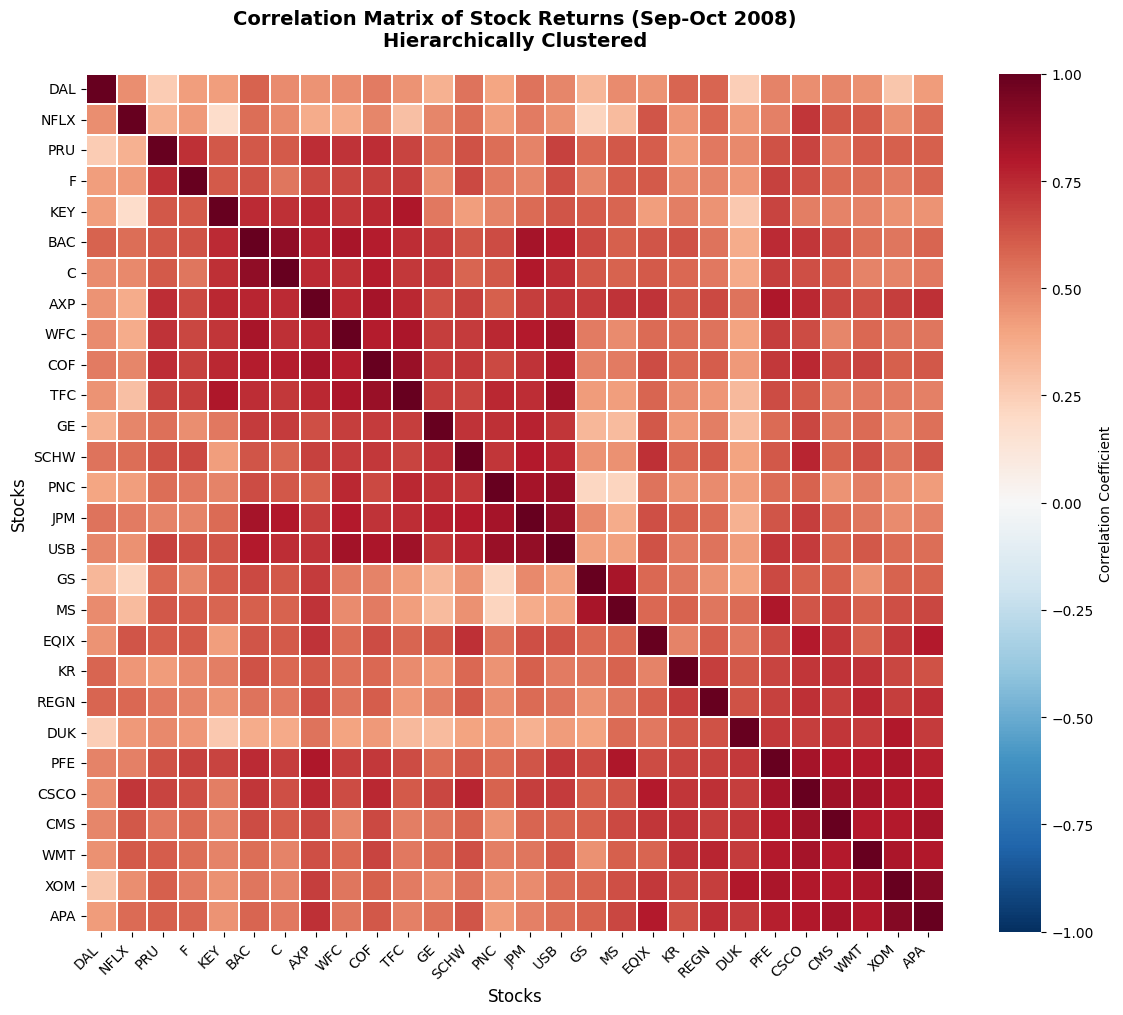

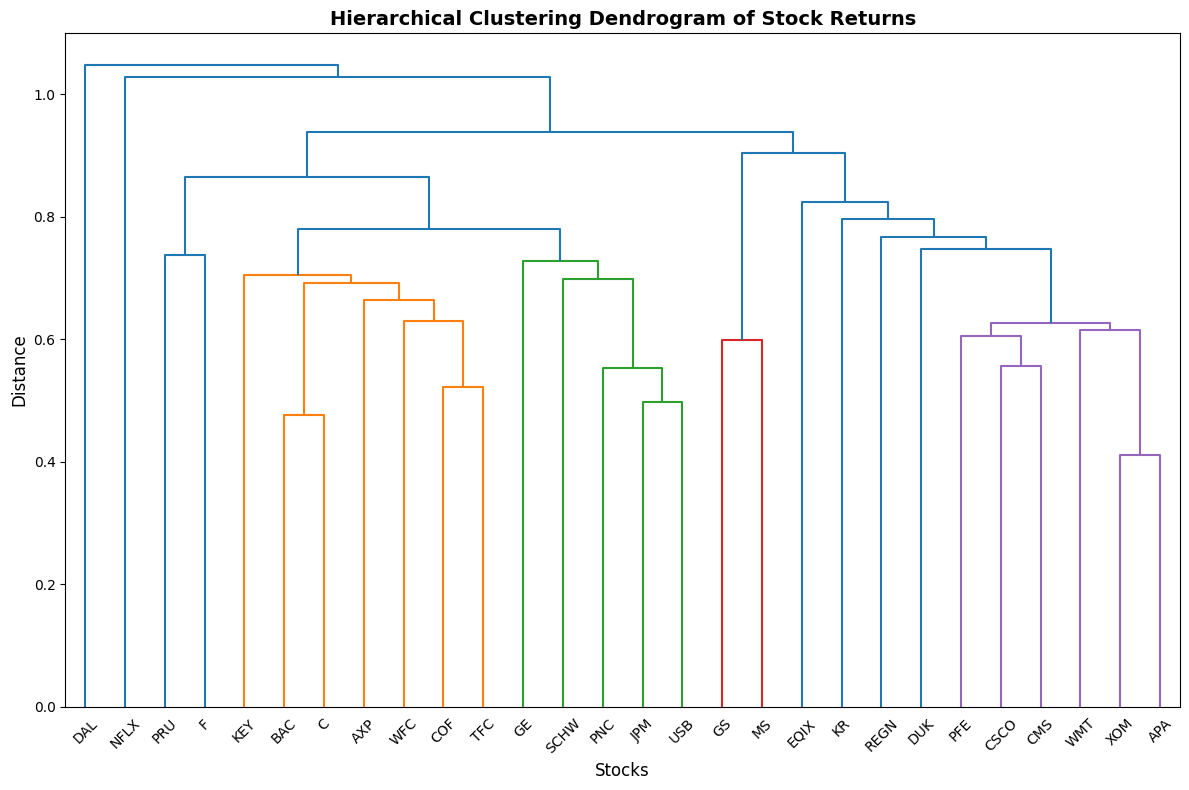

Dendrogram saved to: /Users/alberto/Documents/projects/WQU/stochastimcModeling/report3/images/clustering_dendrogram.png

CORRELATION MATRIX ANALYSIS SUMMARY

Correlation Matrix Statistics:
           JPM      WFC      BAC        C       GS      USB       MS      KEY  \
count  28.0000  28.0000  28.0000  28.0000  28.0000  28.0000  28.0000  28.0000   
mean    0.6387   0.6479   0.6775   0.6390   0.5294   0.6638   0.5634   0.5677   
std     0.1601   0.1498   0.1277   0.1361   0.1650   0.1555   0.1658   0.1706   
min     0.3548   0.3680   0.3684   0.3782   0.2170   0.4120   0.2189   0.1815   
25%     0.5189   0.5333   0.5934   0.5334   0.4428   0.5575   0.4668   0.4548   
50%     0.6131   0.6785   0.6518   0.6186   0.5288   0.6661   0.5864   0.5478   
75%     0.7767   0.7505   0.7515   0.7300   0.6023   0.7681   0.6352   0.6878   
max     1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   

           PNC      COF  ...      DAL     CSCO     EQIX      DUK     NFLX  \
coun

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Load the returns data from Step 3
csv_path = '/Users/alberto/Documents/projects/WQU/stochastimcModeling/report3/returns_2008.csv'

try:
    returns_data = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    print(f"Successfully loaded returns data with shape: {returns_data.shape}")
    print(f"Stocks available: {list(returns_data.columns)}")
except FileNotFoundError:
    print(f"Error: Could not find the CSV file at {csv_path}")
    print("Please make sure the previous step completed successfully.")
    exit()

# Remove any columns with all NaN values
returns_data = returns_data.dropna(axis=1, how='all')
# Remove any rows with all NaN values
returns_data = returns_data.dropna(axis=0, how='all')

if returns_data.empty:
    print("Error: No valid data found in the CSV file.")
    exit()

print(f"Data shape after cleaning: {returns_data.shape}")

def compute_correlation_matrix(returns):
    """
    Compute correlation matrix using the formula from Huo and Fu (2017).
    ρ_{i,j} = (<H_i H_j> - <H_i><H_j>) / sqrt((<H_i^2> - <H_i>^2)(<H_j^2> - <H_j>^2))
    """
    n_stocks = returns.shape[1]
    corr_matrix = np.zeros((n_stocks, n_stocks))
    
    for i in range(n_stocks):
        for j in range(n_stocks):
            Hi = returns.iloc[:, i].dropna()  # Remove NaN values
            Hj = returns.iloc[:, j].dropna()  # Remove NaN values
            
            # Find common valid indices
            common_idx = Hi.index.intersection(Hj.index)
            if len(common_idx) == 0:
                corr_matrix[i, j] = 0
                continue
                
            Hi_common = Hi.loc[common_idx]
            Hj_common = Hj.loc[common_idx]
            
            if len(Hi_common) < 2:  # Need at least 2 observations
                corr_matrix[i, j] = 0
                continue
            
            mean_Hi = Hi_common.mean()
            mean_Hj = Hj_common.mean()
            mean_HiHj = (Hi_common * Hj_common).mean()
            mean_Hi2 = (Hi_common ** 2).mean()
            mean_Hj2 = (Hj_common ** 2).mean()
            
            numerator = mean_HiHj - mean_Hi * mean_Hj
            var_Hi = mean_Hi2 - mean_Hi**2
            var_Hj = mean_Hj2 - mean_Hj**2
            
            # Handle potential numerical issues
            if var_Hi <= 0 or var_Hj <= 0:
                corr_matrix[i, j] = 0
            else:
                denominator = np.sqrt(var_Hi * var_Hj)
                corr_matrix[i, j] = numerator / denominator if denominator != 0 else 0
    
    # Ensure diagonal elements are 1 (correlation of stock with itself)
    np.fill_diagonal(corr_matrix, 1.0)
    
    return pd.DataFrame(corr_matrix, index=returns.columns, columns=returns.columns)

def compute_correlation_matrix_simple(returns):
    """
    Alternative: Use pandas built-in correlation function for comparison.
    """
    return returns.corr()

print("Computing correlation matrix using custom formula...")
corr_matrix = compute_correlation_matrix(returns_data)

print("Computing correlation matrix using pandas built-in function for comparison...")
corr_matrix_pandas = compute_correlation_matrix_simple(returns_data)

# Check for any issues with the correlation matrix
print(f"Correlation matrix shape: {corr_matrix.shape}")
print(f"Any NaN values in custom correlation matrix: {corr_matrix.isna().any().any()}")
print(f"Any infinite values in custom correlation matrix: {np.isinf(corr_matrix.values).any()}")

# Replace any remaining NaN or infinite values
corr_matrix = corr_matrix.fillna(0)
corr_matrix = corr_matrix.replace([np.inf, -np.inf], 0)

def sort_stocks_by_clustering(corr_matrix):
    """
    Sort stocks using hierarchical clustering based on correlation matrix.
    Returns the sorted order of stock tickers.
    """
    try:
        # Convert correlation to distance: d_{i,j} = sqrt(2(1 - ρ_{i,j}))
        # Ensure correlation values are clipped to [-1, 1] range
        corr_clipped = np.clip(corr_matrix.values, -1, 1)
        dist_matrix = np.sqrt(2 * (1 - corr_clipped))
        
        # Ensure the distance matrix is symmetric and non-negative
        dist_matrix = (dist_matrix + dist_matrix.T) / 2
        np.fill_diagonal(dist_matrix, 0)  # Now working with numpy array
        
        # Convert to condensed distance matrix for scipy
        condensed_dist = squareform(dist_matrix)
        
        # Perform hierarchical clustering
        linkage = hierarchy.linkage(condensed_dist, method='average')
        sorted_indices = hierarchy.leaves_list(linkage)
        sorted_stocks = corr_matrix.index[sorted_indices].tolist()
        
        return sorted_stocks, linkage
        
    except Exception as e:
        print(f"Error in clustering: {e}")
        # Return original order if clustering fails
        return list(corr_matrix.index), None

print("Performing hierarchical clustering...")
sorted_stocks, linkage_matrix = sort_stocks_by_clustering(corr_matrix)

# Reorder the correlation matrix based on clustering
sorted_corr_matrix = corr_matrix.loc[sorted_stocks, sorted_stocks]

# Create output directory
output_dir = '/Users/alberto/Documents/projects/WQU/stochastimcModeling/report3/images'
os.makedirs(output_dir, exist_ok=True)

# Generate and save the heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(sorted_corr_matrix, dtype=bool), k=1)  # Optional: mask upper triangle

# Create heatmap with better styling
sns.heatmap(sorted_corr_matrix, 
            cmap='RdBu_r',  # Red-Blue colormap (reversed)
            center=0, 
            vmin=-1, 
            vmax=1,
            annot=False, 
            square=True,
            cbar_kws={'label': 'Correlation Coefficient'},
            linewidths=0.1,
            linecolor='white')

plt.title('Correlation Matrix of Stock Returns (Sep-Oct 2008)\nHierarchically Clustered', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Stocks', fontsize=12)
plt.ylabel('Stocks', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save the heatmap as a .png file
heatmap_path = os.path.join(output_dir, 'correlation_heatmap.png')
plt.savefig(heatmap_path, format='png', dpi=300, bbox_inches='tight')
plt.show()

# Also create a dendrogram to show the clustering structure
if linkage_matrix is not None:
    plt.figure(figsize=(12, 8))
    dendrogram = hierarchy.dendrogram(linkage_matrix, 
                                     labels=corr_matrix.index, 
                                     orientation='top',
                                     leaf_rotation=45,
                                     leaf_font_size=10)
    plt.title('Hierarchical Clustering Dendrogram of Stock Returns', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Stocks', fontsize=12)
    plt.ylabel('Distance', fontsize=12)
    plt.tight_layout()
    
    dendrogram_path = os.path.join(output_dir, 'clustering_dendrogram.png')
    plt.savefig(dendrogram_path, format='png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Dendrogram saved to: {dendrogram_path}")

# Print comprehensive summary information
print("\n" + "="*60)
print("CORRELATION MATRIX ANALYSIS SUMMARY")
print("="*60)

print(f"\nCorrelation Matrix Statistics:")
print(corr_matrix.describe().round(4))

print(f"\nComparison with Pandas Correlation:")
diff = np.abs(corr_matrix - corr_matrix_pandas)
print(f"Maximum difference between custom and pandas correlation: {diff.max().max():.6f}")
print(f"Mean absolute difference: {diff.mean().mean():.6f}")

print(f"\nSorted Stocks Order (from clustering):")
for i, stock in enumerate(sorted_stocks, 1):
    print(f"{i:2d}. {stock}")

print(f"\nCorrelation Matrix Sample (Top-left 5x5):")
sample_size = min(5, corr_matrix.shape[0])
print(corr_matrix.iloc[:sample_size, :sample_size].round(4))

# Analyze correlation patterns
print(f"\nCorrelation Analysis:")
# Remove diagonal (self-correlation = 1)
off_diag_corr = corr_matrix.values[~np.eye(corr_matrix.shape[0], dtype=bool)]
print(f"Mean correlation (excluding diagonal): {np.mean(off_diag_corr):.4f}")
print(f"Std correlation (excluding diagonal): {np.std(off_diag_corr):.4f}")
print(f"Min correlation: {np.min(off_diag_corr):.4f}")
print(f"Max correlation: {np.max(off_diag_corr):.4f}")

# Find most and least correlated pairs
corr_no_diag = corr_matrix.copy()
np.fill_diagonal(corr_no_diag.values, np.nan)

# Most correlated pair
max_corr_idx = np.unravel_index(np.nanargmax(corr_no_diag.values), corr_no_diag.shape)
max_corr_stocks = (corr_matrix.index[max_corr_idx[0]], corr_matrix.columns[max_corr_idx[1]])
max_corr_value = corr_no_diag.iloc[max_corr_idx[0], max_corr_idx[1]]

print(f"\nMost correlated pair: {max_corr_stocks[0]} - {max_corr_stocks[1]} ({max_corr_value:.4f})")

# Least correlated pair
min_corr_idx = np.unravel_index(np.nanargmin(corr_no_diag.values), corr_no_diag.shape)
min_corr_stocks = (corr_matrix.index[min_corr_idx[0]], corr_matrix.columns[min_corr_idx[1]])
min_corr_value = corr_no_diag.iloc[min_corr_idx[0], min_corr_idx[1]]

print(f"Least correlated pair: {min_corr_stocks[0]} - {min_corr_stocks[1]} ({min_corr_value:.4f})")

print(f"\n" + "="*60)
print(f"Heatmap saved to: {heatmap_path}")
print("="*60)

# Optionally save the correlation matrix and sorted order
corr_csv_path = os.path.join('/Users/alberto/Documents/projects/WQU/stochastimcModeling/report3', 
                            'correlation_matrix.csv')
sorted_corr_matrix.to_csv(corr_csv_path)
print(f"Correlation matrix saved to: {corr_csv_path}")

# Save sorted stock order
sorted_order_path = os.path.join('/Users/alberto/Documents/projects/WQU/stochastimcModeling/report3', 
                                'sorted_stocks_order.txt')
with open(sorted_order_path, 'w') as f:
    for i, stock in enumerate(sorted_stocks, 1):
        f.write(f"{i:2d}. {stock}\n")
print(f"Sorted stock order saved to: {sorted_order_path}")

# UCB

In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Pseudocode for UCB1 Algorithm (based on Huo and Fu, 2017, Section 2.3, Equation 2.1)
"""
Algorithm: UCB1 for Sequential Portfolio Selection
Input: Number of trials N, number of assets K, daily returns R_{i,t} for i=1,...,K and t=1,...,N
Output: Portfolio weights ω_t and cumulative wealth S_N

1. Initialize:
   - Set number of plays n_i = 0 and empirical mean reward μ_i = 0 for each asset i
   - Set initial wealth S_0 = 1
2. For t = 1 to N:
   a. If any asset i has n_i = 0, select it and set ω_t = e_i (unit vector for asset i)
   b. Else, compute UCB for each asset: UCB_i = μ_i + sqrt(2 * ln(t) / n_i)
   c. Select asset i_t = argmax_i UCB_i and set ω_t = e_i_t
   d. Observe return R_{i_t,t}
   e. Update: n_i_t += 1, μ_i_t = [(n_i_t - 1) * μ_i_t + R_{i_t,t}] / n_i_t
   f. Update wealth: S_t = S_{t-1} * (1 + ω_t^T R_t)
3. Return sequence of ω_t and final wealth S_N
"""

# Load the returns data from Step 3
csv_path = '/Users/alberto/Documents/projects/WQU/stochastimcModeling/report3/returns_2008.csv'
returns_data = pd.read_csv(csv_path, index_col=0, parse_dates=True)

# UCB1 Algorithm Implementation
def ucb1_algorithm(returns_data, initial_wealth=1.0):
    """
    Implements UCB1 algorithm for portfolio selection.
    Returns portfolio weights, selected assets, and cumulative wealth.
    """
    N = len(returns_data)  # Number of trials (trading days)
    K = len(returns_data.columns)  # Number of assets
    stocks = returns_data.columns
    
    # Initialize variables
    n_i = np.zeros(K)  # Number of times each asset is selected
    mu_i = np.zeros(K)  # Empirical mean reward for each asset
    wealth = [initial_wealth]  # Track wealth over time
    selected_assets = []  # Track selected assets
    portfolio_weights = []  # Track portfolio weights
    
    for t in range(N):
        # Get returns for current trial
        R_t = returns_data.iloc[t].values
        
        # Step 2a: Select unexplored assets first
        if 0 in n_i:
            i_t = np.where(n_i == 0)[0][0]  # Select first unexplored asset
            omega_t = np.zeros(K)
            omega_t[i_t] = 1.0  # Invest all in selected asset
        else:
            # Step 2b: Compute UCB for each asset
            ucb_values = mu_i + np.sqrt(2 * np.log(t + 1) / n_i)
            i_t = np.argmax(ucb_values)
            omega_t = np.zeros(K)
            omega_t[i_t] = 1.0  # Invest all in selected asset
        
        # Step 2d: Observe return
        portfolio_return = omega_t @ R_t
        
        # Step 2e: Update counts and mean rewards
        n_i[i_t] += 1
        mu_i[i_t] = ((n_i[i_t] - 1) * mu_i[i_t] + R_t[i_t]) / n_i[i_t]
        
        # Step 2f: Update wealth
        wealth_t = wealth[-1] * (1 + portfolio_return)
        wealth.append(wealth_t)
        
        # Store results
        selected_assets.append(stocks[i_t])
        portfolio_weights.append(omega_t)
    
    # Convert results to DataFrame
    wealth = wealth[1:]  # Remove initial wealth
    portfolio_weights = pd.DataFrame(portfolio_weights, index=returns_data.index, columns=stocks)
    
    return portfolio_weights, selected_assets, wealth

# Run UCB1 algorithm
portfolio_weights, selected_assets, wealth = ucb1_algorithm(returns_data)

# Compute cumulative wealth for a benchmark (equal-weighted portfolio)
equal_weights = np.ones(len(returns_data.columns)) / len(returns_data.columns)
equal_portfolio_returns = returns_data @ equal_weights
equal_wealth = [1.0]
for ret in equal_portfolio_returns:
    equal_wealth.append(equal_wealth[-1] * (1 + ret))
equal_wealth = equal_wealth[1:]

# Plot cumulative wealth
plt.figure(figsize=(10, 6))
plt.plot(returns_data.index, wealth, label='UCB1 Portfolio', color='blue')
plt.plot(returns_data.index, equal_wealth, label='Equal-Weighted Portfolio', color='orange')
plt.title('Cumulative Wealth: UCB1 vs Equal-Weighted Portfolio (Sep-Oct 2008)')
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Save the plot
plot_path = '/Users/alberto/Documents/projects/WQU/stochastimcModeling/report3/images/ucb1_wealth.png'
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
plt.savefig(plot_path, format='png', dpi=300, bbox_inches='tight')
plt.close()

# Print summary results
print("UCB1 Algorithm Results:")
print(f"Final Cumulative Wealth: {wealth[-1]:.4f}")
print(f"Equal-Weighted Portfolio Wealth: {equal_wealth[-1]:.4f}")
print("\nSelected Assets (First 10 and Last 10):")
print(selected_assets[:10] + selected_assets[-10:])
print("\nPortfolio Weights Sample (First 5 days):")
print(portfolio_weights.head().round(4))
print(f"\nWealth Plot saved to: {plot_path}")


UCB1 Algorithm Results:
Final Cumulative Wealth: 0.8126
Equal-Weighted Portfolio Wealth: 0.7305

Selected Assets (First 10 and Last 10):
['JPM', 'WFC', 'BAC', 'C', 'GS', 'USB', 'MS', 'KEY', 'PNC', 'COF', 'BAC', 'KEY', 'CSCO', 'XOM', 'JPM', 'WMT', 'PFE', 'KR', 'MS', 'USB']

Portfolio Weights Sample (First 5 days):
            JPM  WFC  BAC    C   GS  USB   MS  KEY  PNC  COF  ...  DAL  CSCO  \
Date                                                          ...              
2008-09-03  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0   0.0   
2008-09-04  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0   0.0   
2008-09-05  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0   0.0   
2008-09-08  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0   0.0   
2008-09-09  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  ...  0.0   0.0   

            EQIX  DUK  NFLX   GE  APA    F  REGN  CMS  
Date                                                   
2008-09-03  

# Epsilon-Greedy

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Pseudocode for Epsilon-Greedy Algorithm (based on Huo and Fu, 2017, Section 3.2 and standard definitions)
"""
Algorithm: Epsilon-Greedy for Sequential Portfolio Selection
Input: Number of trials N, number of assets K, daily returns R_{i,t} for i=1,...,K and t=1,...,N, epsilon ε
Output: Portfolio weights ω_t and cumulative wealth S_N

1. Initialize:
   - Set number of plays n_i = 0 and empirical mean reward μ_i = 0 for each asset i
   - Set initial wealth S_0 = 1
2. For t = 1 to N:
   a. Generate random number p ~ Uniform(0,1)
   b. If p < ε:
      - Select random asset i_t from {1,...,K}
      - Set ω_t = e_i_t (unit vector for asset i_t)
   c. Else:
      - Select asset i_t = argmax_i μ_i
      - Set ω_t = e_i_t
   d. Observe return R_{i_t,t}
   e. Update: n_i_t += 1, μ_i_t = [(n_i_t - 1) * μ_i_t + R_{i_t,t}] / n_i_t
   f. Update wealth: S_t = S_{t-1} * (1 + ω_t^T R_t)
3. Return sequence of ω_t and final wealth S_N
"""

# Load the returns data from Step 3
csv_path = '/Users/alberto/Documents/projects/WQU/stochastimcModeling/report3/returns_2008.csv'
returns_data = pd.read_csv(csv_path, index_col=0, parse_dates=True)

# Epsilon-Greedy Algorithm Implementation
def epsilon_greedy_algorithm(returns_data, epsilon=0.1, initial_wealth=1.0):
    """
    Implements epsilon-greedy algorithm for portfolio selection.
    Returns portfolio weights, selected assets, and cumulative wealth.
    """
    N = len(returns_data)  # Number of trials (trading days)
    K = len(returns_data.columns)  # Number of assets
    stocks = returns_data.columns
    
    # Initialize variables
    n_i = np.zeros(K)  # Number of times each asset is selected
    mu_i = np.zeros(K)  # Empirical mean reward for each asset
    wealth = [initial_wealth]  # Track wealth over time
    selected_assets = []  # Track selected assets
    portfolio_weights = []  # Track portfolio weights
    
    for t in range(N):
        # Get returns for current trial
        R_t = returns_data.iloc[t].values
        
        # Step 2a: Generate random number
        p = np.random.uniform(0, 1)
        
        # Step 2b-c: Select asset
        if p < epsilon:
            # Explore: select random asset
            i_t = np.random.randint(0, K)
            omega_t = np.zeros(K)
            omega_t[i_t] = 1.0  # Invest all in selected asset
        else:
            # Exploit: select asset with highest mean reward
            i_t = np.argmax(mu_i)
            omega_t = np.zeros(K)
            omega_t[i_t] = 1.0  # Invest all in selected asset
        
        # Step 2d: Observe return
        portfolio_return = omega_t @ R_t
        
        # Step 2e: Update counts and mean rewards
        n_i[i_t] += 1
        mu_i[i_t] = ((n_i[i_t] - 1) * mu_i[i_t] + R_t[i_t]) / n_i[i_t]
        
        # Step 2f: Update wealth
        wealth_t = wealth[-1] * (1 + portfolio_return)
        wealth.append(wealth_t)
        
        # Store results
        selected_assets.append(stocks[i_t])
        portfolio_weights.append(omega_t)
    
    # Convert results to DataFrame
    wealth = wealth[1:]  # Remove initial wealth
    portfolio_weights = pd.DataFrame(portfolio_weights, index=returns_data.index, columns=stocks)
    
    return portfolio_weights, selected_assets, wealth

# Run epsilon-greedy algorithm with ε = 0.1
epsilon = 0.1
portfolio_weights, selected_assets, wealth = epsilon_greedy_algorithm(returns_data, epsilon=epsilon)

# Compute cumulative wealth for a benchmark (equal-weighted portfolio)
equal_weights = np.ones(len(returns_data.columns)) / len(returns_data.columns)
equal_portfolio_returns = returns_data @ equal_weights
equal_wealth = [1.0]
for ret in equal_portfolio_returns:
    equal_wealth.append(equal_wealth[-1] * (1 + ret))
equal_wealth = equal_wealth[1:]

# Plot cumulative wealth
plt.figure(figsize=(10, 6))
plt.plot(returns_data.index, wealth, label=f'Epsilon-Greedy (ε={epsilon}) Portfolio', color='green')
plt.plot(returns_data.index, equal_wealth, label='Equal-Weighted Portfolio', color='orange')
plt.title('Cumulative Wealth: Epsilon-Greedy vs Equal-Weighted Portfolio (Sep-Oct 2008)')
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Save the plot
plot_path = '/Users/alberto/Documents/projects/WQU/stochastimcModeling/report3/images/epsilon_greedy_wealth.png'
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
plt.savefig(plot_path, format='png', dpi=300, bbox_inches='tight')
plt.close()

# Print summary results
print("Epsilon-Greedy Algorithm Results:")
print(f"Epsilon: {epsilon}")
print(f"Final Cumulative Wealth: {wealth[-1]:.4f}")
print(f"Equal-Weighted Portfolio Wealth: {equal_wealth[-1]:.4f}")
print("\nSelected Assets (First 10 and Last 10):")
print(selected_assets[:10] + selected_assets[-10:])
print("\nPortfolio Weights Sample (First 5 days):")
print(portfolio_weights.head().round(4))
print(f"\nWealth Plot saved to: {plot_path}")

Epsilon-Greedy Algorithm Results:
Epsilon: 0.1
Final Cumulative Wealth: 1.0473
Equal-Weighted Portfolio Wealth: 0.7305

Selected Assets (First 10 and Last 10):
['JPM', 'JPM', 'WFC', 'WFC', 'WFC', 'WFC', 'WFC', 'WFC', 'WFC', 'WFC', 'APA', 'APA', 'APA', 'APA', 'BAC', 'BAC', 'BAC', 'BAC', 'BAC', 'F']

Portfolio Weights Sample (First 5 days):
            JPM  WFC  BAC    C   GS  USB   MS  KEY  PNC  COF  ...  DAL  CSCO  \
Date                                                          ...              
2008-09-03  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0   0.0   
2008-09-04  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0   0.0   
2008-09-05  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0   0.0   
2008-09-08  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0   0.0   
2008-09-09  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0   0.0   

            EQIX  DUK  NFLX   GE  APA    F  REGN  CMS  
Date                                      

# Comparing models

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load the returns data from Step 3
csv_path = '/Users/alberto/Documents/projects/WQU/stochastimcModeling/report3/returns_2008.csv'
returns_data = pd.read_csv(csv_path, index_col=0, parse_dates=True)

# UCB1 Algorithm (from Step 5)
def ucb1_algorithm(returns_data, initial_wealth=1.0):
    N = len(returns_data)
    K = len(returns_data.columns)
    stocks = returns_data.columns
    n_i = np.zeros(K)
    mu_i = np.zeros(K)
    wealth = [initial_wealth]
    selected_assets = []
    portfolio_weights = []
    portfolio_returns = []
    
    for t in range(N):
        R_t = returns_data.iloc[t].values
        if 0 in n_i:
            i_t = np.where(n_i == 0)[0][0]
            omega_t = np.zeros(K)
            omega_t[i_t] = 1.0
        else:
            ucb_values = mu_i + np.sqrt(2 * np.log(t + 1) / n_i)
            i_t = np.argmax(ucb_values)
            omega_t = np.zeros(K)
            omega_t[i_t] = 1.0
        portfolio_return = omega_t @ R_t
        n_i[i_t] += 1
        mu_i[i_t] = ((n_i[i_t] - 1) * mu_i[i_t] + R_t[i_t]) / n_i[i_t]
        wealth_t = wealth[-1] * (1 + portfolio_return)
        wealth.append(wealth_t)
        selected_assets.append(stocks[i_t])
        portfolio_weights.append(omega_t)
        portfolio_returns.append(portfolio_return)
    
    wealth = wealth[1:]
    portfolio_weights = pd.DataFrame(portfolio_weights, index=returns_data.index, columns=stocks)
    portfolio_returns = np.array(portfolio_returns)
    return portfolio_weights, selected_assets, wealth, portfolio_returns

# Epsilon-Greedy Algorithm (from Step 6)
def epsilon_greedy_algorithm(returns_data, epsilon=0.1, initial_wealth=1.0):
    N = len(returns_data)
    K = len(returns_data.columns)
    stocks = returns_data.columns
    n_i = np.zeros(K)
    mu_i = np.zeros(K)
    wealth = [initial_wealth]
    selected_assets = []
    portfolio_weights = []
    portfolio_returns = []
    
    for t in range(N):
        R_t = returns_data.iloc[t].values
        p = np.random.uniform(0, 1)
        if p < epsilon:
            i_t = np.random.randint(0, K)
            omega_t = np.zeros(K)
            omega_t[i_t] = 1.0
        else:
            i_t = np.argmax(mu_i)
            omega_t = np.zeros(K)
            omega_t[i_t] = 1.0
        portfolio_return = omega_t @ R_t
        n_i[i_t] += 1
        mu_i[i_t] = ((n_i[i_t] - 1) * mu_i[i_t] + R_t[i_t]) / n_i[i_t]
        wealth_t = wealth[-1] * (1 + portfolio_return)
        wealth.append(wealth_t)
        selected_assets.append(stocks[i_t])
        portfolio_weights.append(omega_t)
        portfolio_returns.append(portfolio_return)
    
    wealth = wealth[1:]
    portfolio_weights = pd.DataFrame(portfolio_weights, index=returns_data.index, columns=stocks)
    portfolio_returns = np.array(portfolio_returns)
    return portfolio_weights, selected_assets, wealth, portfolio_returns

# Compute regret (difference between optimal and actual rewards)
def compute_regret(portfolio_returns, returns_data):
    """
    Compute cumulative regret as the sum of differences between the maximum possible
    return and the actual portfolio return for each trial.
    """
    max_returns = returns_data.max(axis=1).values
    regret = max_returns - portfolio_returns
    cumulative_regret = np.cumsum(regret)
    return cumulative_regret

# Run algorithms
ucb1_weights, ucb1_assets, ucb1_wealth, ucb1_returns = ucb1_algorithm(returns_data)
epsilon_weights, epsilon_assets, epsilon_wealth, epsilon_returns = epsilon_greedy_algorithm(returns_data, epsilon=0.1)

# Compute equal-weighted portfolio
equal_weights = np.ones(len(returns_data.columns)) / len(returns_data.columns)
equal_portfolio_returns = returns_data @ equal_weights
equal_wealth = [1.0]
for ret in equal_portfolio_returns:
    equal_wealth.append(equal_wealth[-1] * (1 + ret))
equal_wealth = equal_wealth[1:]
equal_returns = equal_portfolio_returns.values

# Compute regrets
ucb1_regret = compute_regret(ucb1_returns, returns_data)
epsilon_regret = compute_regret(epsilon_returns, returns_data)
equal_regret = compute_regret(equal_returns, returns_data)

# Compute variability (standard deviation of portfolio returns)
ucb1_variability = np.std(ucb1_returns)
epsilon_variability = np.std(epsilon_returns)
equal_variability = np.std(equal_returns)

# Plot cumulative wealth
plt.figure(figsize=(10, 6))
plt.plot(returns_data.index, ucb1_wealth, label='UCB1 Portfolio', color='blue')
plt.plot(returns_data.index, epsilon_wealth, label='Epsilon-Greedy (ε=0.1) Portfolio', color='green')
plt.plot(returns_data.index, equal_wealth, label='Equal-Weighted Portfolio', color='orange')
plt.title('Cumulative Wealth Comparison (Sep-Oct 2008)')
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
wealth_plot_path = '/Users/alberto/Documents/projects/WQU/stochastimcModeling/report3/images/wealth_comparison.png'
os.makedirs(os.path.dirname(wealth_plot_path), exist_ok=True)
plt.savefig(wealth_plot_path, format='png', dpi=300, bbox_inches='tight')
plt.close()

# Plot cumulative regret
plt.figure(figsize=(10, 6))
plt.plot(returns_data.index, ucb1_regret, label='UCB1 Regret', color='blue')
plt.plot(returns_data.index, epsilon_regret, label='Epsilon-Greedy (ε=0.1) Regret', color='green')
plt.plot(returns_data.index, equal_regret, label='Equal-Weighted Regret', color='orange')
plt.title('Cumulative Regret Comparison (Sep-Oct 2008)')
plt.xlabel('Date')
plt.ylabel('Cumulative Regret')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
regret_plot_path = '/Users/alberto/Documents/projects/WQU/stochastimcModeling/report3/images/regret_comparison.png'
os.makedirs(os.path.dirname(regret_plot_path), exist_ok=True)
plt.savefig(regret_plot_path, format='png', dpi=300, bbox_inches='tight')
plt.close()

# Print performance metrics
print("Performance Comparison:")
print(f"UCB1 Final Wealth: {ucb1_wealth[-1]:.4f}")
print(f"Epsilon-Greedy (ε=0.1) Final Wealth: {epsilon_wealth[-1]:.4f}")
print(f"Equal-Weighted Final Wealth: {equal_wealth[-1]:.4f}")
print(f"\nUCB1 Variability (Std of Returns): {ucb1_variability:.4f}")
print(f"Epsilon-Greedy Variability (Std of Returns): {epsilon_variability:.4f}")
print(f"Equal-Weighted Variability (Std of Returns): {equal_variability:.4f}")
print(f"\nUCB1 Final Regret: {ucb1_regret[-1]:.4f}")
print(f"Epsilon-Greedy Final Regret: {epsilon_regret[-1]:.4f}")
print(f"Equal-Weighted Final Regret: {equal_regret[-1]:.4f}")
print(f"\nWealth Plot saved to: {wealth_plot_path}")
print(f"Regret Plot saved to: {regret_plot_path}")

Performance Comparison:
UCB1 Final Wealth: 0.8126
Epsilon-Greedy (ε=0.1) Final Wealth: 0.7182
Equal-Weighted Final Wealth: 0.7305

UCB1 Variability (Std of Returns): 0.0772
Epsilon-Greedy Variability (Std of Returns): 0.0690
Equal-Weighted Variability (Std of Returns): 0.0547

UCB1 Final Regret: 4.1161
Epsilon-Greedy Final Regret: 4.2547
Equal-Weighted Final Regret: 4.2756

Wealth Plot saved to: /Users/alberto/Documents/projects/WQU/stochastimcModeling/report3/images/wealth_comparison.png
Regret Plot saved to: /Users/alberto/Documents/projects/WQU/stochastimcModeling/report3/images/regret_comparison.png


# Adapting code

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
from typing import List

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)

# Define the list of 30 S&P 500 stocks with updated tickers
stocks = [
    # Financial institutions
    'JPM', 'WFC', 'BAC', 'C', 'GS', 'USB', 'MS', 'KEY', 'PNC', 'COF',
    'AXP', 'PRU', 'SCHW', 'TFC', 'SIVB',  # TFC for BBT, SIVB for STI
    # Non-financial companies
    'KR', 'PFE', 'XOM', 'WMT', 'DAL', 'CSCO', 'PEAK', 'EQIX', 'DUK', 'NFLX',
    'GE', 'APA', 'F', 'REGN', 'CMS'  # PEAK for HCP
]

# Define the date range for March and April 2020
start_date = '2020-03-01'
end_date = '2020-04-30'

def fetch_stock_data(tickers: List[str], start: str, end: str) -> pd.DataFrame:
    """
    Fetches daily closing prices for a list of tickers within the specified date range.
    Returns a pandas DataFrame with dates as index and tickers as columns.
    """
    try:
        data = yf.download(tickers, start=start, end=end, progress=False, auto_adjust=False)
        if len(tickers) == 1:
            if 'Adj Close' in data.columns:
                data = data[['Adj Close']].rename(columns={'Adj Close': tickers[0]})
            else:
                data = pd.DataFrame()
        else:
            adj_close_data = pd.DataFrame()
            for ticker in tickers:
                try:
                    if (ticker, 'Adj Close') in data.columns:
                        adj_close_data[ticker] = data[(ticker, 'Adj Close')]
                    elif ticker in data.columns and 'Adj Close' in data[ticker].columns:
                        adj_close_data[ticker] = data[ticker]['Adj Close']
                except (KeyError, AttributeError):
                    print(f"Warning: Could not extract data for {ticker}")
                    continue
            data = adj_close_data
        if not data.empty:
            data = data.ffill()
        return data
    except Exception as e:
        print(f"Error fetching data: {e}")
        return pd.DataFrame()

def fetch_data_with_retry(stocks: List[str], start_date: str, end_date: str) -> pd.DataFrame:
    """
    Fetch stock data with retry logic for failed downloads.
    """
    price_data = fetch_stock_data(stocks, start_date, end_date)
    missing_stocks = [stock for stock in stocks if stock not in price_data.columns or price_data[stock].isna().all()]
    
    if missing_stocks:
        print(f"Failed to download data for: {missing_stocks}")
        successful_data = price_data.copy()
        for stock in missing_stocks:
            print(f"Trying individual download for {stock}...")
            individual_data = fetch_stock_data([stock], start_date, end_date)
            if not individual_data.empty and stock in individual_data.columns:
                successful_data[stock] = individual_data[stock]
                print(f"Successfully downloaded {stock}")
            else:
                print(f"Individual download also failed for {stock}")
        return successful_data
    return price_data

# Fetch the data
print("Fetching stock data for March-April 2020...")
price_data = fetch_data_with_retry(stocks, start_date, end_date)

# Verify available stocks
available_stocks = [stock for stock in stocks if stock in price_data.columns and not price_data[stock].isna().all()]
print(f"\nSuccessfully downloaded data for {len(available_stocks)} out of {len(stocks)} stocks:")
print(f"Available stocks: {available_stocks}")

if len(available_stocks) > 0:
    price_data = price_data[available_stocks]
    price_data = price_data.dropna(how='all')
    
    if price_data.empty:
        print("No valid price data available after cleaning.")
    else:
        # Compute daily log returns: R_{i,t} = log(P_{i,t+1} / P_{i,t})
        returns_data = np.log(price_data / price_data.shift(1))
        returns_data = returns_data.dropna()
        
        if returns_data.empty:
            print("No returns data available after processing.")
        else:
            # Save the returns data
            output_dir = '/Users/alberto/Documents/projects/WQU/stochastimcModeling/report3'
            os.makedirs(output_dir, exist_ok=True)
            csv_path = os.path.join(output_dir, 'returns_2020.csv')
            returns_data.to_csv(csv_path)
            print(f"Returns data saved to: {csv_path}")
            
            # Generate a time series plot of returns for a subset of stocks
            plot_stocks = ['JPM', 'BAC', 'NFLX', 'WMT', 'GE']
            available_plot_stocks = [stock for stock in plot_stocks if stock in returns_data.columns]
            if not available_plot_stocks:
                available_plot_stocks = list(returns_data.columns)[:5]
            print(f"Plotting stocks: {available_plot_stocks}")
            
            if available_plot_stocks:
                plt.figure(figsize=(12, 8))
                colors = plt.cm.Set1(np.linspace(0, 1, len(available_plot_stocks)))
                for i, stock in enumerate(available_plot_stocks):
                    plt.plot(returns_data.index, returns_data[stock], 
                             label=stock, color=colors[i], linewidth=1.5, alpha=0.8)
                plt.title('Daily Log Returns of Selected Stocks (Mar-Apr 2020)\nCOVID-19 Market Volatility', 
                          fontsize=14, fontweight='bold')
                plt.xlabel('Date', fontsize=12)
                plt.ylabel('Log Return', fontsize=12)
                plt.legend(loc='upper right', fontsize=10)
                plt.grid(True, alpha=0.3)
                plt.xticks(rotation=45)
                plt.tight_layout()
                
                # Save the plot
                plot_path = '/Users/alberto/Documents/projects/WQU/stochastimcModeling/report3/images/returns_2020_plot.png'
                plt.savefig(plot_path, format='png', dpi=300, bbox_inches='tight')
                plt.close()
                print(f"Plot saved to: {plot_path}")
            
            # Print summary information
            print(f"\n{'='*50}")
            print("DATA SUMMARY")
            print(f"{'='*50}")
            print(f"DataFrame Shape: {returns_data.shape}")
            print(f"Date Range: {returns_data.index[0].strftime('%Y-%m-%d')} to {returns_data.index[-1].strftime('%Y-%m-%d')}")
            print(f"Number of Trading Days: {len(returns_data)}")
            print(f"Stocks with Data: {list(returns_data.columns)}")
            print("\nBasic Statistics:")
            print(returns_data.describe().round(6))
            print(f"\n{'='*50}")
            print("SAMPLE RETURNS DATA (First 10 Days)")
            print(f"{'='*50}")
            print(returns_data.head(10).round(6))
else:
    print("No stock data available for the specified period")
    print("This might be due to:")
    print("1. Delisted companies")
    print("2. Changed ticker symbols")
    print("3. Data availability issues for the 2020 period")
    print("4. Network connectivity issues")

Fetching stock data for March-April 2020...



2 Failed downloads:
['PEAK', 'SIVB']: YFTzMissingError('possibly delisted; no timezone found')


Failed to download data for: ['JPM', 'WFC', 'BAC', 'C', 'GS', 'USB', 'MS', 'KEY', 'PNC', 'COF', 'AXP', 'PRU', 'SCHW', 'TFC', 'SIVB', 'KR', 'PFE', 'XOM', 'WMT', 'DAL', 'CSCO', 'PEAK', 'EQIX', 'DUK', 'NFLX', 'GE', 'APA', 'F', 'REGN', 'CMS']
Trying individual download for JPM...
Successfully downloaded JPM
Trying individual download for WFC...
Successfully downloaded WFC
Trying individual download for BAC...
Successfully downloaded BAC
Trying individual download for C...
Successfully downloaded C
Trying individual download for GS...
Successfully downloaded GS
Trying individual download for USB...
Successfully downloaded USB
Trying individual download for MS...
Successfully downloaded MS
Trying individual download for KEY...
Successfully downloaded KEY
Trying individual download for PNC...
Successfully downloaded PNC
Trying individual download for COF...
Successfully downloaded COF
Trying individual download for AXP...
Successfully downloaded AXP
Trying individual download for PRU...
Succe


1 Failed download:
['SIVB']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['PEAK']: YFTzMissingError('possibly delisted; no timezone found')


Successfully downloaded TFC
Trying individual download for SIVB...
Individual download also failed for SIVB
Trying individual download for KR...
Successfully downloaded KR
Trying individual download for PFE...
Successfully downloaded PFE
Trying individual download for XOM...
Successfully downloaded XOM
Trying individual download for WMT...
Successfully downloaded WMT
Trying individual download for DAL...
Successfully downloaded DAL
Trying individual download for CSCO...
Successfully downloaded CSCO
Trying individual download for PEAK...
Individual download also failed for PEAK
Trying individual download for EQIX...
Successfully downloaded EQIX
Trying individual download for DUK...
Successfully downloaded DUK
Trying individual download for NFLX...
Successfully downloaded NFLX
Trying individual download for GE...
Successfully downloaded GE
Trying individual download for APA...
Successfully downloaded APA
Trying individual download for F...
Successfully downloaded F
Trying individual down

# Runing models for 2020 data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# UCB1 Algorithm (from Step 5)
def ucb1_algorithm(returns_data, initial_wealth=1.0):
    """
    Implements UCB1 algorithm for portfolio selection.
    Returns portfolio weights, selected assets, and cumulative wealth.
    """
    N = len(returns_data)  # Number of trials (trading days)
    K = len(returns_data.columns)  # Number of assets
    stocks = returns_data.columns
    
    # Initialize variables
    n_i = np.zeros(K)  # Number of times each asset is selected
    mu_i = np.zeros(K)  # Empirical mean reward for each asset
    wealth = [initial_wealth]  # Track wealth over time
    selected_assets = []  # Track selected assets
    portfolio_weights = []  # Track portfolio weights
    
    for t in range(N):
        # Get returns for current trial
        R_t = returns_data.iloc[t].values
        
        # Select asset
        if 0 in n_i:
            i_t = np.where(n_i == 0)[0][0]  # Select first unexplored asset
            omega_t = np.zeros(K)
            omega_t[i_t] = 1.0
        else:
            ucb_values = mu_i + np.sqrt(2 * np.log(t + 1) / n_i)
            i_t = np.argmax(ucb_values)
            omega_t = np.zeros(K)
            omega_t[i_t] = 1.0
        
        # Observe return
        portfolio_return = omega_t @ R_t
        
        # Update counts and mean rewards
        n_i[i_t] += 1
        mu_i[i_t] = ((n_i[i_t] - 1) * mu_i[i_t] + R_t[i_t]) / n_i[i_t]
        
        # Update wealth
        wealth_t = wealth[-1] * (1 + portfolio_return)
        wealth.append(wealth_t)
        
        # Store results
        selected_assets.append(stocks[i_t])
        portfolio_weights.append(omega_t)
    
    # Convert results to DataFrame
    wealth = wealth[1:]  # Remove initial wealth
    portfolio_weights = pd.DataFrame(portfolio_weights, index=returns_data.index, columns=stocks)
    
    return portfolio_weights, selected_assets, wealth

# Epsilon-Greedy Algorithm (from Step 6)
def epsilon_greedy_algorithm(returns_data, epsilon=0.1, initial_wealth=1.0):
    """
    Implements epsilon-greedy algorithm for portfolio selection.
    Returns portfolio weights, selected assets, and cumulative wealth.
    """
    N = len(returns_data)
    K = len(returns_data.columns)
    stocks = returns_data.columns
    n_i = np.zeros(K)
    mu_i = np.zeros(K)
    wealth = [initial_wealth]
    selected_assets = []
    portfolio_weights = []
    
    for t in range(N):
        R_t = returns_data.iloc[t].values
        p = np.random.uniform(0, 1)
        if p < epsilon:
            i_t = np.random.randint(0, K)
            omega_t = np.zeros(K)
            omega_t[i_t] = 1.0
        else:
            i_t = np.argmax(mu_i)
            omega_t = np.zeros(K)
            omega_t[i_t] = 1.0
        portfolio_return = omega_t @ R_t
        n_i[i_t] += 1
        mu_i[i_t] = ((n_i[i_t] - 1) * mu_i[i_t] + R_t[i_t]) / n_i[i_t]
        wealth_t = wealth[-1] * (1 + portfolio_return)
        wealth.append(wealth_t)
        selected_assets.append(stocks[i_t])
        portfolio_weights.append(omega_t)
    
    wealth = wealth[1:]
    portfolio_weights = pd.DataFrame(portfolio_weights, index=returns_data.index, columns=stocks)
    
    return portfolio_weights, selected_assets, wealth

# Load the returns data from Step 8
csv_path = '/Users/alberto/Documents/projects/WQU/stochastimcModeling/report3/returns_2020.csv'
returns_data = pd.read_csv(csv_path, index_col=0, parse_dates=True)

# Run algorithms
ucb1_weights, ucb1_assets, ucb1_wealth = ucb1_algorithm(returns_data)
epsilon_weights, epsilon_assets, epsilon_wealth = epsilon_greedy_algorithm(returns_data, epsilon=0.1)

# Compute equal-weighted portfolio
equal_weights = np.ones(len(returns_data.columns)) / len(returns_data.columns)
equal_portfolio_returns = returns_data @ equal_weights
equal_wealth = [1.0]
for ret in equal_portfolio_returns:
    equal_wealth.append(equal_wealth[-1] * (1 + ret))
equal_wealth = equal_wealth[1:]

# Plot cumulative wealth
plt.figure(figsize=(10, 6))
plt.plot(returns_data.index, ucb1_wealth, label='UCB1 Portfolio', color='blue')
plt.plot(returns_data.index, epsilon_wealth, label='Epsilon-Greedy (ε=0.1) Portfolio', color='green')
plt.plot(returns_data.index, equal_wealth, label='Equal-Weighted Portfolio', color='orange')
plt.title('Cumulative Wealth: UCB1 vs Epsilon-Greedy vs Equal-Weighted (Mar-Apr 2020)')
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Save the plot
plot_path = '/Users/alberto/Documents/projects/WQU/stochastimcModeling/report3/images/wealth_2020_comparison.png'
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
plt.savefig(plot_path, format='png', dpi=300, bbox_inches='tight')
plt.close()

# Print summary results
print("Performance Results (March-April 2020):")
print(f"UCB1 Final Wealth: {ucb1_wealth[-1]:.4f}")
print(f"Epsilon-Greedy (ε=0.1) Final Wealth: {epsilon_wealth[-1]:.4f}")
print(f"Equal-Weighted Final Wealth: {equal_wealth[-1]:.4f}")
print("\nUCB1 Selected Assets (First 10 and Last 10):")
print(ucb1_assets[:10] + ucb1_assets[-10:])
print("\nEpsilon-Greedy Selected Assets (First 10 and Last 10):")
print(epsilon_assets[:10] + epsilon_assets[-10:])
print("\nUCB1 Portfolio Weights Sample (First 5 days):")
print(ucb1_weights.head().round(4))
print("\nEpsilon-Greedy Portfolio Weights Sample (First 5 days):")
print(epsilon_weights.head().round(4))
print(f"\nWealth Plot saved to: {plot_path}")

Performance Results (March-April 2020):
UCB1 Final Wealth: 0.5177
Epsilon-Greedy (ε=0.1) Final Wealth: 0.8354
Equal-Weighted Final Wealth: 0.7897

UCB1 Selected Assets (First 10 and Last 10):
['JPM', 'WFC', 'BAC', 'C', 'GS', 'USB', 'MS', 'KEY', 'PNC', 'COF', 'XOM', 'PFE', 'F', 'CSCO', 'CMS', 'REGN', 'WFC', 'NFLX', 'AXP', 'WMT']

Epsilon-Greedy Selected Assets (First 10 and Last 10):
['DUK', 'JPM', 'JPM', 'WFC', 'BAC', 'C', 'C', 'GS', 'USB', 'USB', 'MS', 'MS', 'MS', 'MS', 'MS', 'MS', 'MS', 'MS', 'MS', 'MS']

UCB1 Portfolio Weights Sample (First 5 days):
            JPM  WFC  BAC    C   GS  USB   MS  KEY  PNC  COF  ...  DAL  CSCO  \
Date                                                          ...              
2020-03-03  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0   0.0   
2020-03-04  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0   0.0   
2020-03-05  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0   0.0   
2020-03-06  0.0  0.0  0.0  1.0  0.0  0.0 